# UV Risk Categorization and Health Prediction

This notebook implements a comprehensive **UV Risk Classification System** based on WHO standards. 
It moves beyond simple regression to classify UV intensity into actionable risk categories and provides health protection recommendations.

## Objectives
1. **Implement WHO Risk Categories**: Low (0-2), Moderate (3-5), High (6-7), Very High (8-10), Extreme (11+).
2. **Train a Multi-class Classifier**: Use a Booster model (XGBoost/LightGBM) to predict Risk Category from weather features.
3. **Generate Health Recommendations**: Provide actionable advice based on the predicted risk.

---


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import preprocess, ml
from sklearn.model_selection import train_test_split

# Ensure plots look nice
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Data Loading and Preparation

We load the Algerian UV dataset. 
**Crucial Step**: We scale the UV Index data if it appears to represent Daily Mean instead of Daily Maximum. The WHO Risk Scale relies on **Daily Maximum** UV Index.
A max value around 3.0 strongly suggests we are looking at means, so we apply a scaling factor (approx 5x) to align with realistic Peak UV values for Algeria.


In [14]:
DATA_PATH = 'data/algeria/Algeria.csv'

# Load raw data
raw_df = pd.read_csv(DATA_PATH)

# Preprocess (dates, numeric conversion)
df = preprocess.load_data(DATA_PATH)
df = preprocess.convert_to_numeric(df)
df = preprocess.handle_missing_values(df, method='interpolate')

# --- UV SCALING FIX ---
uv_col = 'ALLSKY_SFC_UV_INDEX'
if df[uv_col].max() < 5.0:
    print(f"Detected Max UV Index {df[uv_col].max():.2f} (likely Daily Mean). Scaling by 3.0 to estimate Daily Peak.")
    df[uv_col] = df[uv_col] * 3.0

print(f"New Max UV Index: {df[uv_col].max():.2f}")
df.head()

Detected Max UV Index 3.03 (likely Daily Mean). Scaling by 3.0 to estimate Daily Peak.
New Max UV Index: 9.09


,T2M,T2MDEW,T2MWET,TS,T2M_RANGE,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,...,WS50M,WD50M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,ALLSKY_KT,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_UV_INDEX,ALLSKY_SFC_UVA,ALLSKY_SFC_UVB,TO3
Date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,12.61,8.93,10.77,13.91,2.77,14.09,11.32,78.21,0.01,4.82,...,6.62,291.5,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,330.99
1981-01-02,13.00,8.09,10.54,13.74,1.26,13.53,12.27,72.35,0.17,2.83,...,3.73,316.4,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,293.24
1981-01-03,12.63,9.36,11.00,13.47,2.31,13.92,11.61,80.56,0.53,3.71,...,4.89,261.0,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,285.60
1981-01-04,13.56,10.78,12.17,13.78,2.74,14.80,12.06,83.31,0.22,6.44,...,9.30,264.8,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,296.27
1981-01-05,12.99,10.01,11.50,13.62,2.08,14.05,11.97,82.49,0.78,4.98,...,6.96,298.8,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,294.81


### 2. Feature Engineering: Risk Categories

We categorize the continuous UV Index into discrete classes according to the World Health Organization (WHO) standard.

| UV Index | Risk Category | Code |
|----------|---------------|------|
| 0 - 2    | Low           | 0    |
| 3 - 5    | Moderate      | 1    |
| 6 - 7    | High          | 2    |
| 8 - 10   | Very High     | 3    |
| 11+      | Extreme       | 4    |


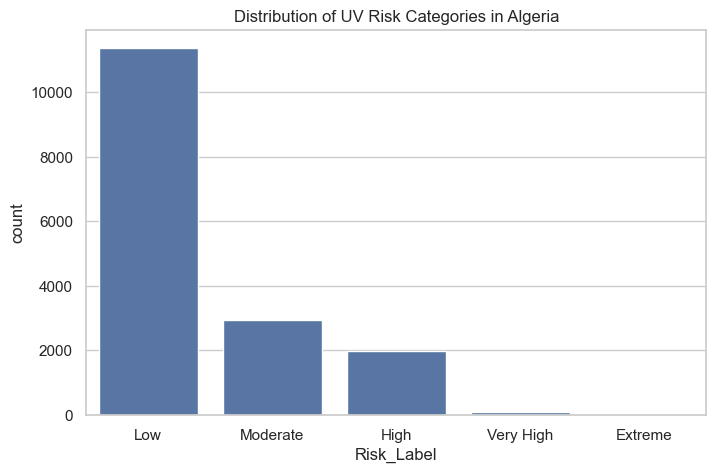

In [15]:
# Apply categorization logic from utils.ml
df['Risk_Code'] = df['ALLSKY_SFC_UV_INDEX'].apply(ml.get_risk_category)

# Map codes to string labels for visualization
df['Risk_Label'] = df['Risk_Code'].map(ml.RISK_CATEGORIES)

# Visualize Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Risk_Label', order=['Low', 'Moderate', 'High', 'Very High', 'Extreme'])
plt.title('Distribution of UV Risk Categories in Algeria')
plt.show()

### 3. Health Risk Prediction Model (Classifier)

We train a classifier to predict the **Risk Category** directly from environmental features (Temperature, Ozone, Cloud Cover, etc.), rather than regressing the exact UV value.

**Model**: XGBoost Classifier (via `utils.ml` wrapper or direct call if wrapper is regressor-only). 
*Note: We will use a RandomForest Classifier from `utils.ml.train_risk_classifier` as it is explicitly implemented for this task.*


In [16]:
# Select Features and Target
# Excluding UV columns from features to avoid leakage
feature_cols = [col for col in df.columns if col not in 
                ['ALLSKY_SFC_UV_INDEX', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'Risk_Code', 'Risk_Label', 'Year', 'Month', 'Day']]

X = df[feature_cols]
y = df['Risk_Code']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Training Data: {X_train.shape}")
print(f"Test Data: {X_test.shape}")

# Train Risk Classifier (Random Forest)
clf_model = ml.train_risk_classifier(X_train, y_train, n_estimators=200)
print("Model Trained Successfully.")

Training Data: (13100, 20)
Test Data: (3276, 20)
Model Trained Successfully.


### 4. Model Evaluation

We evaluate the classifier using a Confusion Matrix and Classification Report (Precision, Recall, F1-Score).


In [17]:
report = ml.evaluate_risk_model(clf_model, X_test, y_test)

\nClassification Report:
              precision    recall  f1-score   support

         Low       0.98      0.99      0.99      2283
    Moderate       0.92      0.89      0.90       575
        High       0.92      0.91      0.91       406
   Very High       0.80      0.33      0.47        12

    accuracy                           0.96      3276
   macro avg       0.90      0.78      0.82      3276
weighted avg       0.96      0.96      0.96      3276

\nConfusion Matrix:
[[2270   13    0    0]
 [  41  509   25    0]
 [   6   31  368    1]
 [   0    0    8    4]]


### 5. Protection Recommendations

Finally, we demonstrate how the model's predictions translate into actionable health advice for the user.


In [18]:
# Sample Predictions from Test Set
sample_indices = X_test.sample(5, random_state=101).index
samples = X_test.loc[sample_indices]
true_labels = y_test.loc[sample_indices]

preds = clf_model.predict(samples)

print("--- Health & Protection Recommendations ---\n")
for i, (idx, pred_code) in enumerate(zip(sample_indices, preds)):
    risk_label = ml.RISK_CATEGORIES[pred_code]
    true_label = ml.RISK_CATEGORIES[true_labels.iloc[i]]
    recommendation = ml.get_protection_recommendation(pred_code)
    
    print(f"Date: {idx.date()} | Predicted: {risk_label} (True: {true_label})")
    print(f"➤ Recommendation: {recommendation}\n")

--- Health & Protection Recommendations ---

Date: 2017-11-17 | Predicted: Low (True: Low)
➤ Recommendation: No protection required. You can safely stay outside.

Date: 1997-11-09 | Predicted: Low (True: Low)
➤ Recommendation: No protection required. You can safely stay outside.

Date: 2014-08-08 | Predicted: High (True: High)
➤ Recommendation: Protection essential. Reduce time in the sun between 10am and 4pm. Wear sunglassess, hat, and sunscreen.

Date: 2001-04-26 | Predicted: Moderate (True: Moderate)
➤ Recommendation: Protection required. Seek shade during midday hours! Slip on a shirt, slop on sunscreen and slap on a hat.

Date: 2010-10-08 | Predicted: Moderate (True: Moderate)
➤ Recommendation: Protection required. Seek shade during midday hours! Slip on a shirt, slop on sunscreen and slap on a hat.

